# Multi-scale VSWIR Imaging Spectroscopy for Critical-Mineral Indicators
## Southern Pine Valley area, southern Wah Wah Range, Beaver County, Utah (Utah Geological Survey AOI)

Authors: K. Dana Chadwick<sup>1</sup>, Erik A. Bolch<sup>2</sup>, Rupsesh Shrestha <sup>3</sup>, Noah J. Christensen<sup>4</sup>

1. Science Systems and Applications, Inc., NASA Goddard Space Flight Center.
2. KBR Inc., contractor to the USGS Earth Observation Research and Science Center, NASA Land Processes Distributed Active Archive Center.
3. ORNL DAAC
4. Utah Geological Survey


Last updated: 08/13/2026

<div class="alert alert-info" role="alert">

An [Earthdata Login](https://urs.earthdata.nasa.gov/) account is required to access data from the NASA Earthdata system, including AVIRIS and EMIT data.

</div>

## Summary

#TODO Notebook Image
#TODO Summary

### Products Used
|Product|Product Page|Collection Shortname|
|:---|:---|:---|
|EMIT L2A Estimated Surface Reflectance and Uncertainty and Masks 60 m V001|https://doi.org/10.5067/EMIT/EMITL2ARFL.001|EMITL2ARFL|
|EMIT L2A Masks 60 m V002|https://doi.org/10.5067/EMIT/EMITL2AMASK.002|EMITL2AMASK|
|EMIT L2B Estimated Mineral Identification and Band Depth and Uncertainty 60 m V001|https://doi.org/10.5067/EMIT/EMITL2BMIN.001|EMITL2BMIN|
|AVIRIS-5 L2A Orthocorrected Surface Reflectance, Facility Instrument Collection|https://doi.org/10.3334/ORNLDAAC/2484|AV5_L2A_RFL_2484|


## Background


Southern Pine Valley sits on the Pioche mineral belt or Blue Ribbon lineamont which consists of Cambian through Devonian carbonates, Oliogocene Needles Range Group ash-flow tufts, and Miocene Blawn Formation rhyolites which contain critical minerals. 

##TODO More mineral info

Because EMIT and AVIRIS resolve the full VSWIR spectral range, they can be used to evaluate the position and width of fan Al-OH feature near 2.2 µm.

<b>References</b>
1. Lindsey, D.A. & Osmonson, L.M. (1978), *Mineral potential of altered rocks near Blawn Mountain Wah Wah Range, Utah*, USGS Open-File Report 78-114;
2. Barkoff, D.W. (2022), *Trace element behaviors during igneous evolution and hydrothermal alteration of an evolved rhyolite, the Blawn Formation, Wah Wah Mountains, Utah*, PhD dissertation, UNLV, DOI 10.34917/35777457;
3. Portela, B. et al. (2025), *Characterising mineral chemistry variation as a proxy for fluid composition using EMIT spaceborne hyperspectral data*, Ore Geology Reviews 182, 106673;
3.Utah Geological Survey, *Geologic map of the Southern Pine Valley area, Beaver County, Utah*, Open-File Report 671 (`data/ofr-671/`);
4. Code lineage: data-access and orthorectification patterns are adapted from NASA LP DAAC, ORNL DAAC, and JPL repositories: `EMIT-Data-Resources`, `VITALS`, `mined-lands`, and `airborne`.

## Requirements
1. A free NASA Earthdata Login: <https://urs.earthdata.nasa.gov/>. `earthaccess` will create a
   `~/.netrc` for you the first time you log in.
2. *No Python setup requirements if connected to the workshop cloud instance!*
3. **Local Only** Set up Python Environment - See **setup_instructions.md** in the `/setup/` folder to set up a local compatible Python environment 
4. This notebook downloads a few GB of EMIT + AVIRIS granules into `./data/` (cached; re-runs skip
   the download).

Data volume note: AVIRIS-5 flight-line reflectance files are large (~2 GB each). The notebook
downloads one representative EMIT scene and one AVIRIS-5 flight line by default.

## Learning Objectives

1. **Search and cloud-screen EMIT L2B mineralogy** over a region of interest, and select a working
   scene by first requiring that it actually contains the indicator suite (a mineral-richness gate)
   and then using season as a tie-break to match the airborne acquisition (using the CMR `CloudCover`
   field and the granule acquisition dates).
2. **Translate Tetracorder mineral IDs** in the L2BMIN product into a named critical-mineral
   indicator suite (alunite, white mica, kaolinite, dickite, pyrophyllite) and map the alteration
   zonation over the districts.
3. **Apply a per-pixel L2A cloud mask** correctly, resolving the flag bands by name rather than by
   index, so clouds cannot leak into the reflectance or the derived products.
4. **Read airborne AVIRIS-5 reflectance** from its NetCDF datatree and measure its true ground
   sampling distance directly from the grid, rather than assuming it.
5. **Quantify the multi-pixel scaling effect**: show how many ~10.4 m AVIRIS pixels fall inside one
   ~60 m EMIT pixel, and how the coarse pixel averages that spread away.
6. **Perform continuum removal and Al-OH feature metrics** (position, depth, width) on both sensors,
   and build a white-mica composition (fluid-pH) proxy map.
7. **Articulate how two scales combine** for critical-mineral targeting in an A-type rhyolite /
   alunite-lithocap system.

## Contents (TODO)
1. [Setup](#1-setup)




In [1]:
#TODO - Add Markdown Explanations where missing

In [2]:
# Import required packages
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry.polygon import orient
from pyproj import CRS, Proj, Transformer 

import matplotlib.pyplot as plt          # spectra and imagery figures
import hvplot.pandas                          # .hvplot on (Geo)DataFrames
import hvplot.xarray                          # .hvplot on xarray DataArrays
import holoviews as hv
hv.extension("bokeh")

import earthaccess

import vitals.emit_tools as et 
import vitals.spectral_utils as su

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 60)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("xarray", xr.__version__, "| earthaccess", earthaccess.__version__)

xarray 2026.7.0 | earthaccess 0.18.0


Authenticate with NASA Earthdata. `persist=True` writes a `~/.netrc` so you only enter
credentials once.

In [3]:
earthaccess.login(persist=True)

# 1.1 Study Area of Interest
The study-area polygon is the UGS Southern Pine Valley AOI (`data/AOI/AOI.shp`), which drives every
data search below. We read it using `geopandas`, reproject to WGS84 lon/lat, and simplify the geometry to a rectanglular polygon and add a name column.

In [4]:
# Open the Southern Pine Valley AOI Shapefile using geopandas and reproject
aoi_gdf = gpd.read_file(DATA_DIR / "AOI" / "AOI.shp").to_crs(epsg=4326)
# Add a Name field for the polygon
aoi_gdf['name'] = ["Southern Pine Valley AOI"]

For our future data search, the query to the NASA common metadata repository (CMR) using `earthaccess`, the API expects a counter-clockwise exterior ring as a list of points, so we orient the coordinate vertices in that order, then convert to a list of points.

In [5]:
# Merge all Polygon geometries and create external boundary
aoi_poly = aoi_gdf.union_all().envelope
# Re-order vertices to counterclockwise
aoi_poly = orient(aoi_poly, sign=1.0)
aoi = list(aoi_poly.exterior.coords)

We can also visualize our search area over a basemap to get a better idea of the terrain in the region.

In [6]:
# Plot the AOI Polygon
aoi_gdf.hvplot.polygons(geo=True, tiles='EsriNatGeo', crs=4326, project=True, line_color='red', line_width=3, frame_width=450, padding=0.5,
                        title="Wah Wah Range, Beaver County, Utah", fontscale=1.2, label=aoi_gdf["name"][0]).opts(legend_position='bottom_right')

:Overlay
   .WMTS.I                            :WMTS   [Longitude,Latitude]
   .Polygons.Southern_Pine_Valley_AOI :Polygons   [Longitude,Latitude]

##TODO - Add text about UGS data

In [7]:
# Geological Groupings are provided by the Utah Geological Survey
geo_units_fp = DATA_DIR / "ofr-671" / "OFR-671DM_SouthernPineValleyArea_Shapefiles" / \
    "SouthernPineValleyArea_GeologicUnits.shp"
# Open with geopandas, reproject, and clip to our AOI
geo_aoi_gdf = gpd.read_file(geo_units_fp).to_crs(epsg=4326).clip(aoi_gdf)
geo_aoi_gdf

,UnitRank,UnitSymbol,UnitLabel,UnitName,Grouping,Age_Strat,Descriptio,Compositio,Genesis,Source,Notes,SHAPE_Leng,SHAPE_Area,geometry
33,7,Ti,Ti,Isom Formation,Isom Formation,Oligocene,"Red brown to purple, crystal-poor ash-flow tuffs and lav...","Densely welded, crystal-poor, vuggy, ash-flow tuff; crys...",Ash-flow tuff,"Best and others, 1987",Map is not modified from original source map even in loc...,4532.581682,7.502939e+05,"POLYGON Z ((-113.68476 38.01912 0, -113.6847 38.01896 0,..."
46,6,Tv,Tv,"Volcanic rocks, undivided",Miocene volcanic rocks,Miocene,Heterogeneous group of rocks that includes: (1) pink to ...,"Breccia and megabreccia of nearby volcanic rocks, weak h...","Tectonic breccia and megabreccia, lava flows, ash-flow tuff","Best and others, 1987",Map is not modified from original source map even in loc...,14412.914649,5.039938e+06,"POLYGON Z ((-113.70938 38.02456 0, -113.70933 38.0245 0,..."
31,6,Tv,Tv,"Volcanic rocks, undivided",Miocene volcanic rocks,Miocene,Heterogeneous group of rocks that includes: (1) pink to ...,"Breccia and megabreccia of nearby volcanic rocks, weak h...","Tectonic breccia and megabreccia, lava flows, ash-flow tuff","Best and others, 1987",Map is not modified from original source map even in loc...,2559.648921,2.360546e+05,"POLYGON Z ((-113.68859 38.01778 0, -113.68864 38.0177 0,..."
60,1,Qa,Qa,Alluvium,Alluvial deposits,Quaternary,"Unconsolidated, poorly sorted, stream, fan, slope-wash, ...","Silt, sand, gravel, cobbles, and boulders",Alluvial,"Best and others, 1987",Map is not modified from original source map even in loc...,10589.984644,2.345198e+06,"POLYGON Z ((-113.73085 38.02297 0, -113.73058 38.02282 0..."
29,6,Tv,Tv,"Volcanic rocks, undivided",Miocene volcanic rocks,Miocene,Heterogeneous group of rocks that includes: (1) pink to ...,"Breccia and megabreccia of nearby volcanic rocks, weak h...","Tectonic breccia and megabreccia, lava flows, ash-flow tuff","Best and others, 1987",Map is not modified from original source map even in loc...,844.602403,2.883855e+04,"POLYGON Z ((-113.68999 38.01775 0, -113.69007 38.01767 0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,1,Qa,Qa,Alluvium,Alluvial deposits,Quaternary,"Unconsolidated, poorly sorted, stream, fan, slope-wash, ...","Silt, sand, gravel, cobbles, and boulders",Alluvial,"Best and others, 1987",Map is not modified from original source map even in loc...,5074.373515,9.840228e+05,"POLYGON Z ((-113.51297 38.22674 0, -113.51313 38.22662 0..."
386,1,Qa,Qa,Alluvium,Alluvial deposits,Quaternary,"Unconsolidated, poorly sorted, stream, fan, slope-wash, ...","Silt, sand, gravel, cobbles, and boulders",Alluvial,"Best and others, 1987",Map is not modified from original source map even in loc...,3856.652877,4.102988e+05,"POLYGON Z ((-113.5008 38.22198 0, -113.50085 38.22198 0,..."
393,19,Dcp,Dcp,Crystal Pass Member of Sultan Limestone and Cover Fort Q...,Devonian sedimentary rocks,Upper Devonian,"Crystal Pass Member is medium- to dark-bluish-gray, medi...","Limestone, dolomite, sandstone, quartzite",Marine,"Best and others, 1987",Map is not modified from original source map even in loc...,5201.280716,4.891587e+05,"POLYGON Z ((-113.54103 38.22625 0, -113.54113 38.22607 0..."
392,18,Mc,Mc,Monte Cristo Limestone,Monte Cristo Limestone,Lower Mississippian,"Medium ­to bluish-gray, medium- to thick-bedded, medium-...","Medium- to thick-bedded, medium- to fine-grained, fossil...",Marine,"Best and others, 1987",Map is not modified from original source map even in loc...,4281.381628,5.311202e+05,"POLYGON Z ((-113.5449 38.22617 0, -113.54489 38.22597 0,..."


Let's visualize these stratigraphic groupings over our AOI to help give our future spectral analysis a geological frame. Plot the AOI and the groupsings using `hvplot`.

In [8]:
# Plot our AOI and the Stratigraphic Groupings
(geo_aoi_gdf.hvplot.polygons(
     geo=True, tiles="EsriWorldTopo", c="Grouping", cmap="tab20",
     alpha=0.65, line_color="#4d4d4d", line_width=0.3,
     hover_cols=["UnitSymbol", "UnitName", "Age"],
     frame_width=700, frame_height=620, legend="right",
     title="UGS OFR-671 geologic units over the Southern Pine Valley AOI",
     fontscale=1.2)
 * aoi_gdf.hvplot.polygons(geo=True, line_color="red", line_width=2.2)
).opts(padding=0.06, xaxis=None, yaxis=None,
       legend_opts={"title": "Stratigraphic grouping","label_text_font_size": "9pt"},
       frame_width=450)

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]   (Grouping,UnitSymbol,UnitName)
   .Polygons.II :Polygons   [Longitude,Latitude]

## 2. Search for EMIT and AVIRIS Data

To view what data collections are available, we can use the `search_datasets` function with the `keyword` argument.

In [9]:
# Retrieve Collections
collections = earthaccess.search_datasets(keyword='EMIT')
# Print Quantity of Results
print(f'Collections found: {len(collections)}')

Collections found: 68


In [10]:
collections_info = [
    {
        'short_name': c['umm']['ShortName'],
        'collection_concept_id': c['meta']['concept-id'],
        'version': c['umm']['Version'],
        'entry_title': c['umm']['EntryTitle']
    }
    for c in collections
]
pd.set_option('display.max_colwidth', 150)
collections_info = pd.DataFrame(collections_info)
collections_info

,short_name,collection_concept_id,version,entry_title
0,EMITL2ARFL,C2408750690-LPCLOUD,001,EMIT L2A Estimated Surface Reflectance and Uncertainty and Masks 60 m V001
1,EMITL1BRAD,C2408009906-LPCLOUD,001,EMIT L1B At-Sensor Calibrated Radiance and Geolocation Data 60 m V001
2,EMITL2BMIN,C2408034484-LPCLOUD,001,EMIT L2B Estimated Mineral Identification and Band Depth and Uncertainty 60 m V001
3,EMITL2BCH4ENH,C3242680113-LPCLOUD,002,EMIT L2B Methane Enhancement Data 60 m V002
4,EMITL2AMASK,C3882545269-LPCLOUD,002,EMIT L2A Masks 60 m V002
...,...,...,...,...
63,Aqua_AMSR-E_L1B_TB,C2698130454-JAXA,NA,Aqua/AMSR-E L1B Brightness Temperature
64,TG07_Soil-Atmosphere_Flux_Km83_926,C2777750487-ORNL_CLOUD,1,"LBA-ECO TG-07 Trace Gas Fluxes, Undisturbed and Logged Sites, Para, Brazil: 2000-2002"
65,bvoc_flux_759,C2780105326-ORNL_CLOUD,1,"SAFARI 2000 BVOC Measurements at Skukuza and Maun Flux Towers, Wet Season 2001"
66,K011_2000_2001_NZ_1,C1214593941-SCIOPS,Not provided,"The concentration of combustion engine particulates, the organic fraction of the particulates and the sources of the particulates identified by is..."


Now that we've identified the concept-id we want to use for our search, lets search for scenes using the `search_data` function. We can also include other query parameters like `polygon` to provide our AOI, `temporal` to provide a range of date times (not used here), and `cloud_cover` to provide a min and max range of cloud cover acceptable.

In [11]:
# Finding Data - EMIT
emit_results = earthaccess.search_data(
    concept_id="C2408034484-LPCLOUD",     
    polygon=aoi,             
    cloud_cover=(0,25)  # Min, Max              
)
len(emit_results)

23

In [12]:
emit_results

[Collection: {'ShortName': 'EMITL2BMIN', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -113.6704330444336, 'Latitude': 39.00804901123047}, {'Longitude': -114.10527801513672, 'Latitude': 38.34513854980469}, {'Longitude': -113.3010482788086, 'Latitude': 37.817596435546875}, {'Longitude': -112.86620330810547, 'Latitude': 38.480506896972656}, {'Longitude': -113.6704330444336, 'Latitude': 39.00804901123047}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-08-22T19:21:23Z', 'EndingDateTime': '2022-08-22T19:21:35Z'}}
 Size(MB): 96.39891815185547
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BMIN.001/EMIT_L2B_MIN_001_20220822T192123_2223413_013/EMIT_L2B_MIN_001_20220822T192123_2223413_013.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BMIN.001/EMIT_L2B_MIN_001_20220822T192123_2223413_013/EMIT_L2B_MINUNCERT_001_20220822T192123_22

Similar to previously, we can identify the `concept_id` via a collection search (not shown) and search for AVIRIS scenes using the same parameters for our AOI.

In [13]:
# Finding Data - AVIRIS
av5_results = earthaccess.search_data(
    concept_id="C4184090548-ORNL_CLOUD",
    polygon=aoi,            
)
len(av5_results)

10

In [14]:
av5_results

[Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -113.77732607179077, 'Latitude': 38.35676352734376}, {'Longitude': -113.78298468288318, 'Latitude': 38.228838116647054}, {'Longitude': -113.53329708082872, 'Latitude': 38.22172149587157}, {'Longitude': -113.52720135200737, 'Latitude': 38.34961437286439}, {'Longitude': -113.77732607179077, 'Latitude': 38.35676352734376}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-07-23T16:54:54Z', 'EndingDateTime': '2025-07-23T16:56:42Z'}}
 Size(MB): 4867.963682174683
 Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250723t163747_010_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250723t163747_010_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data

## Choosing an EMIT Scene (TODO - Revise this?)

Our EMIT and AVIRIS-5 searches above return many candidate granules. We now need to pick an
EMIT L2BMIN scene to use for our mineral identifications. We can build a quick overview table from the search results to examine which scene may be best.

For this we will look at:
1. **Scene Cloud-Cover Percentage**
2. **Observation Time**
3. **Viewing and Solar Geometry**
4. **Quantity of Pixels Identified as Alteration Indicators** 

Since our target is bedrock mineralogy and unlikely to change significantly on the timescale of 2 years, we can consider other acquisition information more strongly than just date. Factors like snow, illumination, and clouds can affect identification.

### Search results as a `GeoDataFrame`

The `earthaccess` results are a list of granule objects. We can convert them into a `GeoDataFrame` to help us conduct spatial operations more easily. We will also add a column to evaluate the portion of our AOI that falls within the EMIT Scene.

In [15]:
def results_to_gdf(results: list, aoi: gpd.GeoDataFrame = None, keep_cols: list = None):
    """Convert a list of earthaccess results into a GeoDataFrame.

    If `aoi` is provided, adds two overlap columns computed in an equal-area CRS (EPSG:8857):
      frac_of_aoi     - fraction of the AOI covered by the granule  (use this to rank scenes)
      frac_of_granule - fraction of the granule falling inside the AOI
    """
    df = pd.json_normalize(results)
    # Flatten the nested UMM field names (e.g. "umm.CloudCover" -> "CloudCover")
    df.columns = [c.split(".")[-1] if "." in c else c for c in df.columns]

    gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries(results, crs=4326), crs="EPSG:4326")
    gdf["shortname"] = [r["umm"]["CollectionReference"]["ShortName"] for r in results]
    gdf["data"] = [r.data_links() for r in results]   # asset URLs, straight from the metadata
    gdf["result"] = list(results)                     # keep the granule objects for streaming later

    default_cols = ["native-id", "concept-id", "BeginningDateTime", "EndingDateTime",
                    "CloudCover", "DayNightFlag", "geometry", "shortname", "data", "result"]
    keep = default_cols if not keep_cols else list(dict.fromkeys(keep_cols + default_cols))
    gdf = gdf[[c for c in keep if c in gdf.columns]]

    gdf["datetime"] = pd.to_datetime(gdf["BeginningDateTime"], format="ISO8601").dt.tz_localize(None)

    if aoi is not None:
        # Equal-area projection so the ratios are true area ratios, not degree-squared ratios.
        gdf_eq = gdf.to_crs("EPSG:8857")
        aoi_eq = aoi.to_crs("EPSG:8857").union_all()
        inter = gdf_eq.geometry.intersection(aoi_eq).area
        gdf["frac_of_aoi"] = inter / aoi_eq.area
        gdf["frac_of_granule"] = inter / gdf_eq.geometry.area

    return gdf

### Mineral Identifications in L2BMIN

The EMIT L2B Mineralogy product (L2BMIN) is produced by the **Tetracorder** expert system, which compares each pixel's continuum-removed reflectance against a library of reference spectra. Each pixel can receive up to two identifications: `group_1` covers the ~1 µm region where iron-bearing minerals absorb, and `group_2` covers 2.0-2.5 µm, where our Al-OH sulfates and phyllosilicates absorb.

For each group the file stores a `group_{1,2}_mineral_id`, an integer pointing into a spectral library, and a `group_{1,2}_band_depth` describing how strong the absorption is. To translate those integers into names we use the mineral grouping matrix included in this repository at `data/mineral_grouping_matrix_20230503.csv`.

### Defining an Indicator Suite

The spectral library contains hundreds of entries, but for this alteration system we care about five minerals: **alunite** and **pyrophyllite** (acidic, advanced argillic), **kaolinite** and **dickite** (argillic), and **white mica** (near-neutral halo). Together they record the acidity of the fluid that altered these rocks.

The library splits these into many named variants, so we collapse them into five classes by matching on the mineral name. Note the ordered checks in `classify_name` below - some library entries are compound, like `muscovite+pyrophyllite`, so we test the more diagnostic mineral first.

In [16]:
# Read the EMIT mineral grouping matrix, which maps library indices to mineral names
matrix = pd.read_csv(DATA_DIR / "mineral_grouping_matrix_20230503.csv")

def classify_name(name):
    """Assign a spectral library mineral name to one of our five indicator classes.

    Returns None for library entries that are not alteration indicators. Order matters here:
    compound names like "muscovite+pyrophyllite" are resolved by testing the more diagnostic
    mineral first.
    """
    n = str(name).lower()
    if "alunite" in n:  return "Alunite"
    if "dickite" in n:  return "Dickite"
    if "kaolin" in n:   return "Kaolinite"
    if "pyrophyl" in n and "musc" not in n: return "Pyrophyllite"
    if any(k in n for k in ("muscovite", "illite", "sericite")): return "White mica"
    return None

# Tag every library entry, then keep the indices belonging to each indicator class
matrix["indicator"] = matrix["Name"].apply(classify_name)
INDICATOR_IDS = {cls: matrix.loc[matrix.indicator == cls, "Index"].astype(int).tolist()
                 for cls in ["Alunite", "White mica", "Kaolinite", "Dickite", "Pyrophyllite"]}
# A flat list of every indicator index, used to test "is this pixel any indicator at all?"
ALL_INDICATOR_IDS = sorted({i for ids in INDICATOR_IDS.values() for i in ids})

print("Spectral library entries per indicator class:")
for cls, ids in INDICATOR_IDS.items():
    print(f"  {cls:13s} {len(ids):3d}")

# The alunite variants give a sense of how detailed the library is
print("\nAlunite entries in the library:")
for nm in matrix.loc[matrix.indicator == "Alunite", "Name"]:
    print("  -", nm)

Spectral library entries per indicator class:
  Alunite        20
  White mica     11
  Kaolinite       4
  Dickite         1
  Pyrophyllite    3

Alunite entries in the library:
  - Alunite GDS97 K Syn (150C) W2R4Na
  - Alunite GDS96 K Syn (250C) W2R4Na
  - Alunite RES-2 K Syn (450C) W2R4Na
  - Alunite GDS95 Na Syn (150C) W2R4Na
  - Alunite RES-4 Na Syn (300C) W2R4Na
  - Alunite RES-3 Na Syn (450C) W2R4Na
  - Alunite GDS82 Na82 W1R1Bb
  - Alunite+Dickite MV99-6-26b W1R1Fc
  - Alunite GDS83 Na63 W1R1Bb
  - Alunite RES-9 Summitv (400C) W2R4Nb
  - Alunite GDS84 Na03 W2R4Na
  - Alunite RES10 NA56% Syn 450C W2R4Na
  - Alunite RES12 NA78% Syn 450C W2R4NaIS
  - Alunite0.35K+.65Na CU91-217H W2R4Nb
  - Alunite0.73K+.27Na CU91-217D W2R4Na
  - Alunite0.66K+.34Na CU91-217A W2R4Nb
  - Alunite+Pyrophyl SD1093A W1R1Bb
  - Alunite0.5+Kaol_KGa-1 AMX3 W1R1Bb
  - Alunite.5+MuscCU91-250A AMX4 W1R1Ba
  - Alunite_NH4+Jaro NMNH145596A W1R1Bb


### Counting Indicator Pixels

Now we can open a scene and ask how many pixels in our study area EMIT identified as one of our indicator minerals. The function below uses three `emit_tools` calls in the order that costs the least: `emit_xarray` opens the file in raw sensor space, `spatial_subset` crops to the AOI before we orthorectify, and `ortho_xr` places the result on a lat/lon grid.

We count a pixel if either group carries an indicator id, with no quality threshold. This is the permissive question - did EMIT see this mineral here at all? We add band depth and fit thresholds later.

### Choosing a Data Access Workflow

This notebook supports a download based or streaming workflow, selected by commenting out one block in the cell below. Everything afterwards calls the same `get_assets` function.

The **download workflow** is usually the best pathway if outside the cloud and working on a local computer. The **streaming workflow** is typically recommended if working in the AWS us-west-2 cloud, where connection speeds are very fast.

Rather than editing URLs by hand, we ask `earthaccess` for the link we want: `data_links(access="external")` returns HTTPS URLs, and `data_links(access="direct")` returns the matching `s3://` URLs. The provider name comes from the granule metadata, so the same function works for both the LP DAAC and ORNL DAAC collections.

In [17]:
#TODO Improve this functionality

# =============================================================================
# DATA ACCESS -- comment out one of the two blocks below
# =============================================================================

# --- LOCAL WORKFLOW: download to data/ and open from disk --------------------
def get_assets(granule, contains):
    """Download this granule's matching assets and return their local paths."""
    # Match on the file name only. The granule's directory name repeats the primary asset name,
    # so matching against the full URL would also catch its companion files.
    urls = [u for u in granule.data_links(access="external")
            if u.endswith(".nc") and any(c in u.split("/")[-1] for c in contains)]
    paths = []
    for url in urls:
        path = DATA_DIR / url.split("/")[-1]
        if path.exists() and path.stat().st_size > 0:
            print("cached:", path.name)
        else:
            print("downloading:", path.name)
            earthaccess.download([url], local_path=str(DATA_DIR))
        paths.append(path)
    return paths

# --- CLOUD WORKFLOW (AWS us-west-2): stream directly from S3 -----------------
# def get_assets(granule, contains):
#     """Open this granule's matching assets straight from S3, with no download."""
#     urls = [u for u in granule.data_links(access="direct")
#             if u.endswith(".nc") and any(c in u.split("/")[-1] for c in contains)]
#     for u in urls:
#         print("opening:", u.split("/")[-1])
#     return earthaccess.open(urls,
#                             provider=granule["meta"]["provider-id"],
#                             open_kwargs={"max_concurrency": 20})

In [18]:
def indicator_counts(granule, aoi_gdf):
    """Open one L2BMIN granule, clip it to the AOI, and count indicator pixels.

    Returns a dictionary with the number of valid AOI pixels, the total number carrying any
    indicator identification, and a breakdown by indicator class.
    """
    fp = get_assets(granule, ["_L2B_MIN_"])[0]   # local path or S3 file object

    ds = et.emit_xarray(fp, ortho=False)   # open in raw sensor space (fast)
    ds = et.spatial_subset(ds, aoi_gdf)    # crop to the AOI before orthorectifying
    ds = et.ortho_xr(ds)                   # warp onto a lat/lon grid

    g1 = ds["group_1_mineral_id"].values   # ~1 um identifications
    g2 = ds["group_2_mineral_id"].values   # 2.0-2.5 um identifications

    counts = {"valid_px": int(np.sum(g1 > -9999))}   # -9999 marks no data
    # A pixel counts if EITHER group carries an indicator id
    counts["indicator_px"] = int(np.sum(np.isin(g1, ALL_INDICATOR_IDS)
                                        | np.isin(g2, ALL_INDICATOR_IDS)))
    for cls, ids in INDICATOR_IDS.items():
        counts[cls] = int(np.sum(np.isin(g1, ids) | np.isin(g2, ids)))
    return counts

In [19]:
# Screen the first few scenes from our search. Each takes roughly 10-15 seconds to stream and
# count, so we start small -- raise N_SCENES to look at more of the search results.
N_SCENES = 4

rows = []
for granule in emit_results[:N_SCENES]:
    name = granule["umm"]["GranuleUR"]
    print(f"screening {name} ...")
    rows.append({"granule": name, **indicator_counts(granule, aoi_gdf)})

screened = pd.DataFrame(rows)
# What fraction of the valid AOI pixels carry an indicator identification?
screened["indicator_frac"] = screened["indicator_px"] / screened["valid_px"]
screened

screening EMIT_L2B_MIN_001_20220822T192123_2223413_013 ...
cached: EMIT_L2B_MIN_001_20220822T192123_2223413_013.nc
screening EMIT_L2B_MIN_001_20230420T200006_2311013_012 ...
cached: EMIT_L2B_MIN_001_20230420T200006_2311013_012.nc
screening EMIT_L2B_MIN_001_20230424T182248_2311412_013 ...
cached: EMIT_L2B_MIN_001_20230424T182248_2311412_013.nc
screening EMIT_L2B_MIN_001_20230627T170614_2317811_011 ...
cached: EMIT_L2B_MIN_001_20230627T170614_2317811_011.nc


,granule,valid_px,indicator_px,Alunite,White mica,Kaolinite,Dickite,Pyrophyllite,indicator_frac
0,EMIT_L2B_MIN_001_20220822T192123_2223413_013,161313,2495,906,673,753,22,141,0.015467
1,EMIT_L2B_MIN_001_20230420T200006_2311013_012,180386,5017,2149,616,1805,45,402,0.027813
2,EMIT_L2B_MIN_001_20230424T182248_2311412_013,176712,3700,2177,187,740,32,564,0.020938
3,EMIT_L2B_MIN_001_20230627T170614_2317811_011,17418,0,0,0,0,0,0,0.000000


Two things are worth noting in the table above.

Every one of these scenes images the same rocks, yet the totals differ substantially. Bedrock mineralogy does not change from month to month, so this spread reflects the retrieval rather than the geology - L2BMIN identifications are sensitive to illumination, dust, surface moisture, and the atmospheric correction.

The per-class columns also matter as much as the total. Later we compare an alunite site against a white-mica site, so a scene needs pixels in both classes to be useful.

## 3. Working with a Single Scene

We now select a scene to work with. For now we take the one with the most indicator pixels, which gives us the clearest example of the alteration system.

> TODO - Which scene is genuinely best deserves more thought - coverage of the study area, cloud cover, and illumination all matter - but that discussion is beyond the scope of this notebook.

In [20]:
# Take the scene with the most indicator pixels from our screening table
best = screened.loc[screened["indicator_px"].idxmax()]
sel_name = best["granule"]
# Recover the matching granule object from the original search results
sel_result = next(g for g in emit_results if g["umm"]["GranuleUR"] == sel_name)

print(f"Working scene: {sel_name}")
print(f"  {best['indicator_px']:,} indicator pixels of {best['valid_px']:,} valid AOI pixels "
      f"({best['indicator_frac']:.2%})")

Working scene: EMIT_L2B_MIN_001_20230420T200006_2311013_012
  5,017 indicator pixels of 180,386 valid AOI pixels (2.78%)


### 3.1 Adding Quality Thresholds

The screening above was deliberately permissive. For mapping we want confident identifications, so we add two gates: **band depth**, from the L2BMIN file, describing how deep the absorption is, and **fit**, from the companion **L2BMINUNCERT** file, describing how well the library spectrum matched the pixel.

> The `fit` values are stored at half scale, so we multiply by two before comparing them to our threshold.

The thresholds below are adapted from the USGS `mined-lands` acid-mine-drainage workflow, and are worth experimenting with.

In [21]:
# Both files come from the same granule, so one call fetches each in turn
def open_emit_l2b(granule, pattern, aoi_gdf):
    """Open an EMIT L2B file, crop it to the AOI, and orthorectify it."""
    fp = get_assets(granule, [pattern])[0]
    ds = et.emit_xarray(fp, ortho=False)
    ds = et.spatial_subset(ds, aoi_gdf)
    return et.ortho_xr(ds)

ds_min = open_emit_l2b(sel_result, "_L2B_MIN_", aoi_gdf)        # mineral ids + band depths
ds_unc = open_emit_l2b(sel_result, "_L2B_MINUNCERT_", aoi_gdf)  # fit values for those ids
ds_min

cached: EMIT_L2B_MIN_001_20230420T200006_2311013_012.nc
cached: EMIT_L2B_MINUNCERT_001_20230420T200006_2311013_012.nc


<xarray.Dataset> Size: 4MB
Dimensions:             (latitude: 389, longitude: 486, mineral_name: 294)
Coordinates:
  * latitude            (latitude) float64 3kB 38.23 38.23 38.23 ... 38.02 38.02
  * longitude           (longitude) float64 4kB -113.7 -113.7 ... -113.5 -113.5
    elev                (latitude, longitude) float32 756kB -9.999e+03 ... -9...
  * mineral_name        (mineral_name) object 2kB 'Plastic_Tarp GDS339 Green ...
    index               (mineral_name) float64 2kB ...
    record              (mineral_name) float64 2kB ...
    url                 (mineral_name) object 2kB ...
    group               (mineral_name) float64 2kB ...
    library             (mineral_name) object 2kB ...
    spatial_ref         int64 8B 0
Data variables:
    group_1_band_depth  (latitude, longitude) float32 756kB -9.999e+03 ... -9...
    group_1_mineral_id  (latitude, longitude) float32 756kB -9.999e+03 ... -9...
    group_2_band_depth  (latitude, longitude) float32 756kB -9.999e+03 ... -9...
    group_2_mineral_id  (latitude, longitude) float32 756kB -9.999e+03 ... -9...
Attributes: (12/40)
    ncei_template_version:             NCEI_NetCDF_Swath_Template_v2.0
    summary:                           The Earth Surface Mineral Dust Source ...
    keywords:                          Imaging Spectroscopy, minerals, EMIT, ...
    Conventions:                       CF-1.63
    sensor:                            EMIT (Earth Surface Mineral Dust Sourc...
    instrument:                        EMIT
    ...                                ...
    geotransform:                      [-1.13737885e+02  5.42232520e-04  0.00...
    day_night_flag:                    Day
    title:                             EMIT L2B Estimated Mineral Identificat...
    granule_id:                        EMIT_L2B_MIN_001_20230420T200006_23110...
    subset_downtrack_range:            [368, 867]
    subset_crosstrack_range:           [725, 1210]

### 3.2 The Mineral Library

The L2BMIN file does not store mineral names per pixel, it stores integer ids that point into a spectral library. That library travels with the file as coordinate variables along a `mineral_name` dimension, so we can pull it into a DataFrame for a readable lookup.

For the data, the 0 represents no match. Zero is not stored as a library row, so we add it ourselves at index `-1` and sort, which puts it at row 0 and keeps the DataFrame positions lined up with the ids stored in the data.

> This is the same table as `mineral_grouping_matrix_20230503.csv` - all 294 entries match on index and name. We used the CSV earlier because we needed the indices before opening a scene.

In [22]:
# For the data, the 0 represents no match. For convenience, let's make a DataFrame that holds the
# mineral data, and add that 'No match' reference to it:
min_df = pd.DataFrame({x: ds_min[x].values
                       for x in [var for var in ds_min.coords if 'mineral_name' in ds_min[var].dims]})
min_df.loc[-1] = {'index': 0, 'mineral_name': 'No_Match', 'record': -1.0,
                  'url': 'NA', 'group': 1.0, 'library': 'NA'}
min_df = min_df.sort_index().reset_index(drop=True)
min_df

,index,record,mineral_name,url,group,library
0,0.0,-1.0,No_Match,NA,1.0,NA
1,1.0,6858.0,Plastic_Tarp GDS339 Green W1R1Fa,https://crustal.usgs.gov/speclab/data/HTMLmetadata/Plastic_Tarp_GDS339_Green_ASDFRa_AREF.html,1.0,splib06
2,2.0,744.0,Hematite.02+Quartz.98 GDS76 W1R1Ha,https://crustal.usgs.gov/speclab/data/HTMLmetadata/Hematite.02+Quartz.98_GDS76_BECKa_AREF.html,1.0,sprlb06
3,3.0,882.0,Goethite WS222 <250um MedGrn W1R1H_ AREF,https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goethite_WS222_Medium_Gr._BECKa_AREF.html,1.0,sprlb06
4,4.0,5736.0,Goethite0.02+Quartz GDS240 W1R1Ba,https://crustal.usgs.gov/speclab/data/HTMLmetadata/Goethite0.02+Quartz_GDS240_BECKa_AREF.html,1.0,splib06
...,...,...,...,...,...,...
290,290.0,624.0,Vermiculite GDS458 W1R1Hc,No available USGS Spectral Library 7 Description Reference,2.0,sprlb06
291,291.0,630.0,Vermiculite ALB4SA00 W1R1Hc,No available USGS Spectral Library 7 Description Reference,2.0,sprlb06
292,292.0,636.0,Vermiculite WS682 W1R1Hc,No available USGS Spectral Library 7 Description Reference,2.0,sprlb06
293,293.0,642.0,Vermiculite WS681 W1R1Hc,https://crustal.usgs.gov/speclab/data/HTMLmetadata/Vermiculite_WS681_BECKc_AREF.html,2.0,sprlb06


In [23]:
# With the lookup in place we can read the scene's identifications as names rather than numbers.
# Here are the minerals EMIT identified most often in the 2.0-2.5 um region across our study area.
ids, counts = np.unique(ds_min["group_2_mineral_id"].values, return_counts=True)
valid = ids >= 0                                     # ignore the -9999 no-data value
name_of = dict(zip(min_df["index"], min_df["mineral_name"]))

top = (pd.DataFrame({"mineral_id": ids[valid].astype(int), "pixels": counts[valid]})
         .assign(mineral_name=lambda d: d["mineral_id"].map(name_of))
         .sort_values("pixels", ascending=False)
         .head(12)
         .reset_index(drop=True))
top

,mineral_id,pixels,mineral_name
0,0,84204,No_Match
1,216,21181,Calcite+Dolomite.5 AMX8 W1R1Bb
2,215,19240,Calcite WS272 W1R1Ha
3,227,16929,Calcite+.33Muscov AMX5 Ruby W1R1Ba
4,97,15646,Grass_Golden_Dry GDS480 W1R1Fa
5,99,6293,Plastic_Tarp GDS340 Blu_Wovn W1R1Fa
6,100,5832,Plastic_Vinyl GDS372 White W1R1Fa
7,119,1648,Alunite GDS84 Na03 W2R4Na
8,232,1233,Calcite.7+Kaolwxl.3 AMX9 W1R1Ba
9,133,1114,Kaolinite CM9 (wxl) W1R1Hb


In [24]:
BAND_DEPTH_MIN = 0.02   # minimum absorption depth for a detection we trust
FIT_MIN = 0.40          # minimum library-match quality

# Map every indicator library index to its class, so we can test pixels by class membership
id_to_indicator = {int(row["Index"]): row["indicator"]
                   for _, row in matrix.dropna(subset=["indicator"]).iterrows()}

def indicator_mask(ds, ds_unc, group, indicator):
    """Boolean AOI mask: pixels identified as `indicator` that pass both quality gates.

    EMIT reports up to two identifications per pixel, so callers usually check both groups and
    combine them with OR.
    """
    ids = ds[f"group_{group}_mineral_id"].values
    bd = ds[f"group_{group}_band_depth"].values
    fit = ds_unc[f"group_{group}_fit"].values * 2.0    # stored at half scale - undo it

    is_class = np.isin(ids, [k for k, v in id_to_indicator.items() if v == indicator])
    passes_quality = (bd >= BAND_DEPTH_MIN) & (fit >= FIT_MIN)
    return is_class & passes_quality

# Compare confident detections against the permissive counts from our screening
INDICATOR_ORDER = ["Alunite", "Pyrophyllite", "Kaolinite", "Dickite", "White mica"]
confident = {}
for ind in INDICATOR_ORDER:
    m1 = indicator_mask(ds_min, ds_unc, 1, ind)
    m2 = indicator_mask(ds_min, ds_unc, 2, ind)
    confident[ind] = int(np.nansum(m1 | m2))

pd.DataFrame({"all detections": {k: int(best[k]) for k in INDICATOR_ORDER},
              "passing quality gates": confident})

,all detections,passing quality gates
Alunite,2149,2149
Pyrophyllite,402,393
Kaolinite,1805,1805
Dickite,45,45
White mica,616,614


### 3.3 Mapping the Indicators

Now we turn those masks into a map. Each pixel is coloured by the strongest indicator it carries, scanning both mineral groups and keeping whichever detection has the greatest band depth.

The colours run from the acidic end of the system to the near-neutral end, so reading the progression across the map is reading the pH gradient of the altering fluid.

In [25]:
# Fixed colour per indicator, ordered acidic -> near-neutral
INDICATOR_COLORS = {"Alunite": "#d7191c", "Pyrophyllite": "#fdae61", "Kaolinite": "#ffffbf",
                    "Dickite": "#abd9e9", "White mica": "#2c7bb6"}

# Build a categorical raster: for each pixel keep the indicator with the deepest absorption
ny, nx = ds_min["group_1_band_depth"].shape
class_arr = np.full((ny, nx), np.nan)   # winning class number per pixel, NaN where nothing detected
best_bd = np.zeros((ny, nx))            # band depth of the current winner, so we can compare

for class_num, ind in enumerate(INDICATOR_ORDER, start=1):
    for group in (1, 2):
        m = indicator_mask(ds_min, ds_unc, group, ind)
        bd = np.nan_to_num(ds_min[f"group_{group}_band_depth"].values)
        deeper = m & (bd > best_bd)     # only overwrite if this detection is stronger
        class_arr[deeper] = class_num
        best_bd[deeper] = bd[deeper]

print(f"pixels with a confident indicator identification: {int(np.isfinite(class_arr).sum()):,}")

pixels with a confident indicator identification: 5,006


In [ ]:
#TODO - Improve the legend to show names?
# Wrap the classified array as a DataArray so hvplot can place it on a map
indicator_da = xr.DataArray(
    class_arr,
    dims=("latitude", "longitude"),
    coords={"latitude": ds_min["latitude"].values, "longitude": ds_min["longitude"].values},
    name="indicator",
)

(indicator_da.hvplot.image(
     x="longitude", y="latitude", geo=True, tiles="EsriImagery",
     cmap=[INDICATOR_COLORS[i] for i in INDICATOR_ORDER],
     clim=(0.5, len(INDICATOR_ORDER) + 0.5),
     alpha=0.75, frame_width=600, frame_height=560,
     title=f"EMIT L2BMIN alteration indicators\n{sel_name}")
 * aoi_gdf.hvplot.polygons(geo=True, line_color="red", line_width=2)
).opts(hv.opts.Image(color_levels=len(INDICATOR_ORDER)),      # 5 discrete colour bands, not a ramp
       hv.opts.Overlay(xaxis=None, yaxis=None))

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Image.I    :Image   [longitude,latitude]   (indicator)
   .Polygons.I :Polygons   [Longitude,Latitude]

The colourbar runs 1-5 in the order listed in `INDICATOR_ORDER`: **1 Alunite, 2 Pyrophyllite,
3 Kaolinite, 4 Dickite, 5 White mica**.

> **A caution on interpretation.** The EMIT documentation notes that while the ten standard mineral
> groups are well validated, many of the finer library constituents "require further validation,
> particularly in the case of resource exploration." Treat these detections as indicators that point
> to where follow-up is worthwhile - which is exactly what we do next with the airborne data.

---
## 4. EMIT Reflectance at the Indicator Sites

The L2BMIN product tells us which mineral EMIT identified. The L2A reflectance product shows us the spectrum that led to that call, and it is what we compare against the airborne data later.

L2A reflectance is a separate granule from L2BMIN, so we search for it and match on the orbit and scene numbers both share. These files are a few GB each, so in the download workflow this is the first sizeable transfer of the notebook.

In [27]:
# Find the L2A reflectance granule matching our working scene, using the shared orbit/scene suffix
scene_suffix = "_".join(sel_name.split("_")[-2:])           # e.g. "2311013_012"
rfl_results = earthaccess.search_data(short_name="EMITL2ARFL", polygon=aoi, count=500)
rfl_result = next(r for r in rfl_results if r["umm"]["GranuleUR"].endswith(scene_suffix))

fp_rfl = get_assets(rfl_result, ["_L2A_RFL_"])[0]
fp_mask = get_assets(rfl_result, ["_L2A_MASK_"])[0]

cached: EMIT_L2A_RFL_001_20230420T200006_2311013_012.nc
cached: EMIT_L2A_MASK_001_20230420T200006_2311013_012.nc


### 4.1 Applying the Cloud Mask

Our search excluded scenes that were mostly cloudy, but that is a scene-level filter and says nothing about which pixels are affected. The L2A MASK file carries per-pixel flags, which we use to drop cloud, the buffer ring around each cloud, and cirrus.

> Note that we look the flag bands up **by name** rather than by position. The ordering in the file is not guaranteed, so hard-coding indices is a quiet way to mask the wrong thing.

In [28]:
# Read the flag band names so we can find the cloud flags by name rather than by position
mask_bands = list(xr.open_dataset(fp_mask, engine="h5netcdf",
                                  group="sensor_band_parameters")["mask_bands"].values)
print("available flags:", mask_bands)

CLOUD_FLAGS = ["Cloud flag", "Dilated Cloud Flag", "Cirrus flag"]
cloud_idx = [mask_bands.index(name) for name in CLOUD_FLAGS]

qmask = et.quality_mask(fp_mask, cloud_idx)   # 1 = drop this pixel
print(f"cloud-masked pixels: {int(np.nansum(qmask)):,} of {qmask.size:,} "
      f"({100 * np.nansum(qmask) / qmask.size:.1f}% of the scene)")

available flags: ['Cloud flag', 'Cirrus flag', 'Water flag', 'Spacecraft Flag', 'Dilated Cloud Flag', 'AOD550', 'H2O (g cm-2)', 'Aggregate Flag']
Flags used: ['Cloud flag' 'Dilated Cloud Flag' 'Cirrus flag']
cloud-masked pixels: 48,333 of 1,589,760 (3.0% of the scene)


In [29]:
# Open the reflectance with the cloud mask applied, then crop to the AOI and orthorectify.
# Masked pixels are set to the fill value (-9999) which we convert to NaN below.
ds_rfl = et.emit_xarray(fp_rfl, ortho=False, qmask=qmask)
ds_rfl = et.spatial_subset(ds_rfl, aoi_gdf)
ds_rfl = et.ortho_xr(ds_rfl)

# Fill values -> NaN, and blank out the bands EMIT flags as unusable (deep atmospheric absorption)
ds_rfl["reflectance"] = ds_rfl["reflectance"].where(ds_rfl["reflectance"] != -9999)
good = ds_rfl["good_wavelengths"].values.astype(bool)
ds_rfl["reflectance"].data[:, :, ~good] = np.nan

wl_emit_um = su.to_micrometers(ds_rfl["wavelengths"].values)
print(f"EMIT bands: {wl_emit_um.size}  |  {wl_emit_um.min():.3f} - {wl_emit_um.max():.3f} um")

EMIT bands: 285  |  0.381 - 2.493 um


### 4.2 Selecting Two Sites

For the rest of the notebook we follow two locations: one in the alunite core and one in the white-mica halo. For each we take the pixel with the deepest absorption for that mineral, which gives us the clearest example EMIT found in our study area.

> These are EMIT's own identifications rather than independent ground truth, so treat them as well-supported starting points rather than confirmed occurrences.

In [30]:
def deepest_pixel(indicator, group_order=(2, 1)):
    """Latitude/longitude of the pixel with the strongest confident detection of `indicator`.

    Group 2 (the 2.0-2.5 um region) is checked first because that is where our Al-OH minerals
    absorb most distinctively.
    """
    best = None
    for group in group_order:
        m = indicator_mask(ds_min, ds_unc, group, indicator)
        bd = np.where(m, np.nan_to_num(ds_min[f"group_{group}_band_depth"].values), np.nan)
        if np.all(np.isnan(bd)):
            continue
        iy, ix = np.unravel_index(np.nanargmax(bd), bd.shape)
        if best is None or bd[iy, ix] > best[0]:
            best = (bd[iy, ix],
                    float(ds_min["latitude"].values[iy]),
                    float(ds_min["longitude"].values[ix]))
    return None if best is None else (best[1], best[2])

alunite_pt = deepest_pixel("Alunite")
wmica_pt = deepest_pixel("White mica")
print("alunite core     (lat, lon):", alunite_pt)
print("white-mica halo  (lat, lon):", wmica_pt)

alunite core     (lat, lon): (38.02725624024177, -113.60259817265155)
white-mica halo  (lat, lon): (38.17799688087304, -113.52072106209283)


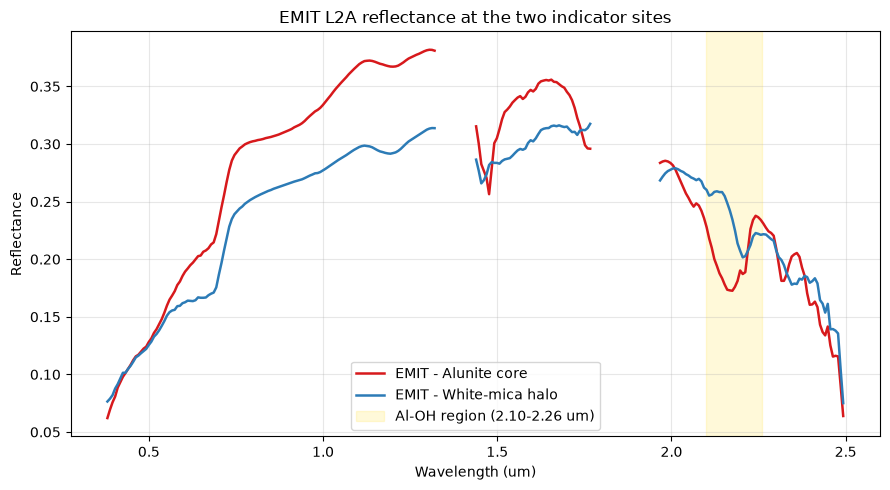

In [31]:
def emit_spectrum(lat, lon):
    """Reflectance spectrum of the EMIT pixel nearest to (lat, lon)."""
    pixel = ds_rfl.sel(latitude=lat, longitude=lon, method="nearest")
    return wl_emit_um, pixel["reflectance"].values

SITES = [("Alunite core", alunite_pt, "#d7191c"),
         ("White-mica halo", wmica_pt, "#2c7bb6")]

fig, ax = plt.subplots(figsize=(9, 5))
for label, pt, color in SITES:
    if pt is None:
        continue
    w, r = emit_spectrum(*pt)
    ax.plot(w, r, color=color, lw=1.8, label=f"EMIT - {label}")

# Both of our indicator minerals absorb near 2.2 um - the feature we analyse in detail later
ax.axvspan(2.10, 2.26, color="gold", alpha=0.15, label="Al-OH region (2.10-2.26 um)")
ax.set_xlabel("Wavelength (um)"); ax.set_ylabel("Reflectance")
ax.set_title("EMIT L2A reflectance at the two indicator sites")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "emit_spectra.png", dpi=130); plt.show()


## 5. Airborne Reflectance from AVIRIS-5

EMIT gives us regional screening at ~60 m. AVIRIS-5 flies a similar instrument on an aircraft, so it sees the same spectral features at a much finer ground sampling distance (GSD), which lets us check what EMIT is averaging over.

Because AVIRIS-5 is airborne, its GSD depends on flight altitude rather than a fixed orbit, and ranges from roughly 0.5 m to 15 m across campaigns. We read the actual value from the file rather than assume one.

Each flight line covers a narrow strip, so first we use `results_to_gdf` to find which line overlaps our study area most.

In [32]:
# Turn the AVIRIS search results into a GeoDataFrame with an AOI-overlap column, then rank
av5_gdf = results_to_gdf(av5_results, aoi=aoi_gdf).sort_values("frac_of_aoi", ascending=False)

av5_gdf[["native-id", "BeginningDateTime", "frac_of_aoi"]].head()

,native-id,BeginningDateTime,frac_of_aoi
3,AV520250723t201709_006_L2A_RFL_1,2025-07-23T20:27:04Z,0.525332
7,AV520250923t194231_005_L2A_RFL_1,2025-09-23T19:50:00Z,0.162095
2,AV520250723t201709_005_L2A_RFL_1,2025-07-23T20:25:16Z,0.082290
5,AV520250730t165108_010_L2A_RFL_1,2025-07-30T17:08:11Z,0.026250
9,AV520250923t204930_006_L2A_RFL_1,2025-09-23T20:57:26Z,0.017990


### 5.1 A Note on File Size

AVIRIS-5 reflectance files are around 4.5 GB each, and are chunked as `(10, 256, 256)` blocks across wavelength, northing, and easting. That layout reads small spatial windows efficiently, but pulling a single full band means touching hundreds of chunks scattered through the file.

> This is the heaviest step in the notebook. In the download workflow the file is transferred once and cached; in the cloud workflow it is opened in place.

In [33]:
# A single flight line covers a narrow strip, so we pair the best line with whichever other line
# adds the most new coverage. Lines from the same acquisition share a wavelength grid and map
# projection, so they tile together without resampling.
av_eq = av5_gdf.to_crs("EPSG:8857").geometry     # equal-area, for honest area comparisons
aoi_eq = aoi_gdf.to_crs("EPSG:8857").union_all()

best_i = av5_gdf.index[0]
gains = {i: av_eq[best_i].union(av_eq[i]).intersection(aoi_eq).area / aoi_eq.area
         for i in av5_gdf.index[1:]}
partner_i = max(gains, key=gains.get)

av5_selected = av5_gdf.loc[[best_i, partner_i]]
print("selected flight lines:")
for i in av5_selected.index:
    print(f"   {av5_gdf.loc[i, 'native-id']:34s} {av5_gdf.loc[i, 'frac_of_aoi']:.1%} of the AOI alone")
print(f"   -> combined coverage: {gains[partner_i]:.1%}")

selected flight lines:
   AV520250723t201709_006_L2A_RFL_1   52.5% of the AOI alone
   AV520250723t201709_005_L2A_RFL_1   8.2% of the AOI alone
   -> combined coverage: 59.3%


In [34]:
# Fetch both lines, then open each as a datatree. The reflectance cube lives at
# ['reflectance']['reflectance'] with easting/northing map coordinates.
av5_paths = [get_assets(av5_selected.loc[i, "result"], ["RFL_ORT"])[0] for i in av5_selected.index]

cubes = [xr.open_datatree(p, engine="h5netcdf", chunks={})["reflectance"]["reflectance"].to_dataset()
         for p in av5_paths]

# The two strips overlap slightly and are offset in easting, so their combined easting axis is not a
# simple concatenation. `merge` with join="outer" builds the union grid and fills the corners that
# neither line covers with NaN; `combine_by_coords` cannot do this and raises on the non-monotonic axis.
av_rfl = xr.merge(cubes, compat="override", join="outer")["reflectance"]

# CRS and grid come from the first line - both share them, as checked above
av5_dt = xr.open_datatree(av5_paths[0], engine="h5netcdf")
av_crs = CRS.from_cf(av5_dt.dataset["transverse_mercator"].attrs)
AV_GSD = float(np.median(np.abs(np.diff(av_rfl["easting"].values))))
av_wl_um = su.to_micrometers(av_rfl["wavelength"].values)

print(f"merged cube : {dict(av_rfl.sizes)}")
print(f"CRS         : {av_crs.name} (EPSG:{av_crs.to_epsg()})")
print(f"GSD         : {AV_GSD:.2f} m   <- measured from the grid, not assumed")
print(f"bands       : {av_wl_um.size}  |  {av_wl_um.min():.3f} - {av_wl_um.max():.3f} um")

cached: AV520250723t201709_006_L2A_OE_da8b3ef7_RFL_ORT.nc
downloading: AV520250723t201709_005_L2A_OE_da8b3ef7_RFL_ORT.nc


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

merged cube : {'wavelength': 424, 'northing': 4279, 'easting': 1453}
CRS         : WGS 84 / UTM zone 11N (EPSG:32611)
GSD         : 10.50 m   <- measured from the grid, not assumed
bands       : 424  |  0.381 - 2.499 um


### 5.2 Matching the Sites to the Flight Lines

The sites we picked in section 4 were the strongest detections anywhere in the study area, which does
not guarantee they fall inside a flight line. The AVIRIS lines cover roughly 60% of the AOI, so before
comparing scales we re-select a matched pair constrained to where we actually have airborne data.

> Footprint containment alone is not enough. A flight line is a narrow diagonal strip, but its
> metadata footprint is a rough quadrilateral whose corners cover ground the sensor never imaged. A
> point can sit inside the polygon and still land on no-data pixels, which would give a flat,
> meaningless spectrum. So we also require the merged cube to carry real reflectance there.

In [35]:
av_proj_sel = Proj(av_crs)
av_e0, av_e1 = float(av_rfl["easting"].min()), float(av_rfl["easting"].max())
av_n0, av_n1 = float(av_rfl["northing"].min()), float(av_rfl["northing"].max())

def aviris_has_data(lat, lon, min_valid=0.5):
    """True if the nearest AVIRIS pixel to (lat, lon) carries real reflectance rather than fill."""
    x, y = av_proj_sel(lon, lat)
    if not (av_e0 <= x <= av_e1 and av_n0 <= y <= av_n1):
        return False
    r = av_rfl.sel(easting=x, northing=y, method="nearest").values.astype("float64")
    return np.mean(np.isfinite(r) & (r > 0)) >= min_valid

def deepest_pixel_in_swath(indicator, group_order=(2, 1)):
    """Strongest detection of `indicator` that also has usable AVIRIS data underneath it."""
    for group in group_order:
        m = indicator_mask(ds_min, ds_unc, group, indicator)
        bd = np.where(m, np.nan_to_num(ds_min[f"group_{group}_band_depth"].values), np.nan)
        if np.all(np.isnan(bd)):
            continue
        # Walk candidates from deepest to shallowest and take the first with airborne coverage
        for flat in np.argsort(np.nan_to_num(bd.ravel(), nan=-1))[::-1]:
            if not np.isfinite(bd.ravel()[flat]):
                break
            iy, ix = np.unravel_index(flat, bd.shape)
            lat = float(ds_min["latitude"].values[iy])
            lon = float(ds_min["longitude"].values[ix])
            if aviris_has_data(lat, lon):
                return (lat, lon)
    return None

alunite_pt_av = deepest_pixel_in_swath("Alunite")
wmica_pt_av = deepest_pixel_in_swath("White mica")

# These matched sites drive every multi-scale figure from here on
SITES = [("Alunite core", alunite_pt_av, "#d7191c"),
         ("White-mica halo", wmica_pt_av, "#2c7bb6")]

for label, pt, _ in SITES:
    if pt is None:
        print(f"WARNING: no {label} pixel with both a detection and AVIRIS coverage")
    else:
        print(f"{label:16s} (lat, lon): {pt[0]:.5f}, {pt[1]:.5f}")

Alunite core     (lat, lon): 38.04515, -113.70779
White-mica halo  (lat, lon): 38.19155, -113.63134


### 5.3 True Colour Imagery

Before interpreting any mineral map it is worth looking at the scene. Below we build a true colour composite from each sensor (red ~650 nm, green ~560 nm, blue ~470 nm) and place them side by side, which makes the difference in spatial detail immediately visible.

> In the EMIT panel, cloud-masked pixels appear as gaps rather than bright cloud tops. The AVIRIS-5 panel is not cloud-masked, so scan it for cloud and shadow before reading anything into the spectra. The two sensors also flew on different dates, so their cloud patterns will not match.

In [36]:
#TODO Change this to how EMIT/AVIRIS browse scenes are created with equalize_hist
def stretch(rgb, lo=2, hi=98):
    """Percentile contrast stretch to [0, 1], ignoring NaN.

    Reflectance values sit in a narrow range, so a plain min/max scaling looks washed out. Mapping
    the 2nd-98th percentiles instead spreads the mid-tones and ignores a few extreme pixels.
    """
    out = np.empty_like(rgb, dtype="float64")
    for b in range(rgb.shape[-1]):
        band = rgb[..., b]
        finite = band[np.isfinite(band)]
        if finite.size == 0:
            out[..., b] = 0.0
            continue
        p_lo, p_hi = np.percentile(finite, [lo, hi])
        out[..., b] = np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)
    return np.nan_to_num(out)

def nearest_band(wavelengths, target_um):
    """Index of the band closest to a target wavelength (bands are not on round numbers)."""
    return int(np.nanargmin(np.abs(np.asarray(wavelengths) - target_um)))

RGB_UM = (0.650, 0.560, 0.470)   # red, green, blue

# EMIT is small enough to slice directly
emit_rgb = stretch(ds_rfl["reflectance"].values[:, :, [nearest_band(wl_emit_um, t) for t in RGB_UM]])
emit_lon, emit_lat = ds_rfl["longitude"].values, ds_rfl["latitude"].values

# For AVIRIS we read only the three visible bands out of the 424 available
av_rgb = stretch(np.transpose(
    av_rfl.isel(wavelength=[nearest_band(av_wl_um, t) for t in RGB_UM]).values, (1, 2, 0)))
av_east, av_north = av_rfl["easting"].values, av_rfl["northing"].values
print("RGB composites ready")

RGB composites ready


In [ ]:
#TODO - Fix merging of scenes

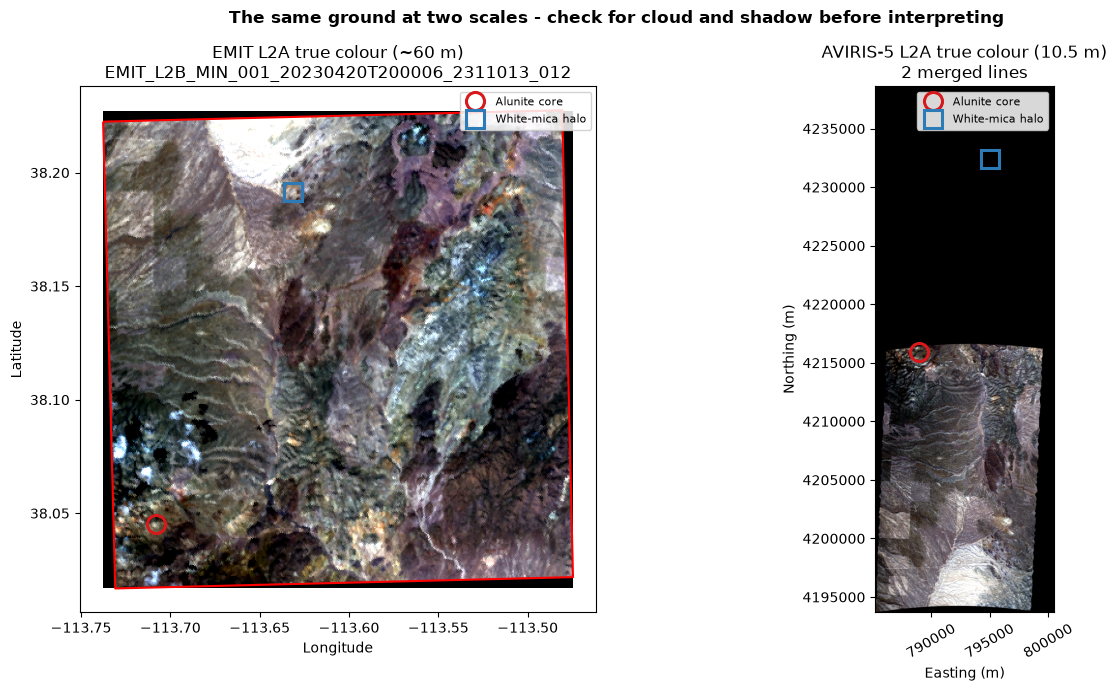

In [37]:
# Project our two sites into the AVIRIS map coordinates for the right-hand panel
to_av = Transformer.from_crs("EPSG:4326", av_crs, always_xy=True)
markers = [("Alunite core", alunite_pt_av, "o", "#d7191c"),
           ("White-mica halo", wmica_pt_av, "s", "#2c7bb6")]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(emit_rgb, origin="upper", aspect="auto",
               extent=[emit_lon.min(), emit_lon.max(), emit_lat.min(), emit_lat.max()])
aoi_gdf.boundary.plot(ax=axes[0], color="red", linewidth=1.5)
for label, pt, mk, color in markers:
    if pt:
        axes[0].plot(pt[1], pt[0], mk, mfc="none", mec=color, mew=2.2, ms=13, label=label)
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.85)
axes[0].set_title(f"EMIT L2A true colour (~60 m)\n{sel_name}")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# northing is descending (row 0 is the northernmost), which is what origin="upper" expects
axes[1].imshow(av_rgb, origin="upper", aspect="equal",
               extent=[av_east.min(), av_east.max(), av_north.min(), av_north.max()])
for label, pt, mk, color in markers:
    if pt:
        x, y = to_av.transform(pt[1], pt[0])
        axes[1].plot(x, y, mk, mfc="none", mec=color, mew=2.2, ms=13, label=label)
axes[1].legend(loc="upper right", fontsize=8, framealpha=0.85)
axes[1].set_title(f"AVIRIS-5 L2A true colour ({AV_GSD:.1f} m)\n{len(av5_paths)} merged lines")
axes[1].set_xlabel("Easting (m)"); axes[1].set_ylabel("Northing (m)")
axes[1].ticklabel_format(style="plain", useOffset=False)
axes[1].tick_params(axis="x", labelrotation=30)

fig.suptitle("The same ground at two scales - check for cloud and shadow before interpreting",
             fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR / "emit_aviris_rgb.png", dpi=130); plt.show()

## 6. Comparing the Two Scales

A single ~60 m EMIT pixel covers the same ground as many AVIRIS-5 pixels. Rather than comparing one EMIT spectrum against one AVIRIS spectrum, we gather every AVIRIS pixel whose centre falls inside the EMIT pixel footprint.

First, work out how many airborne pixels we should expect to find inside one EMIT pixel.

In [38]:
# One EMIT pixel spans one grid step in latitude and longitude
emit_dlat = float(np.median(np.abs(np.diff(ds_rfl["latitude"].values))))
emit_dlon = float(np.median(np.abs(np.diff(ds_rfl["longitude"].values))))

# Convert that to metres so we can predict how many AVIRIS pixels should fit inside
m_per_deg_lat = 111_132.0
m_per_deg_lon = 111_320.0 * np.cos(np.radians(float(np.mean(ds_rfl["latitude"].values))))
emit_m_ns, emit_m_ew = emit_dlat * m_per_deg_lat, emit_dlon * m_per_deg_lon

print(f"EMIT pixel footprint: {emit_m_ns:.1f} m x {emit_m_ew:.1f} m")
print(f"AVIRIS-5 GSD: {AV_GSD:.1f} m")
print(f"  -> roughly {round((emit_m_ns / AV_GSD) * (emit_m_ew / AV_GSD))} AVIRIS pixels "
      f"per EMIT pixel")

EMIT pixel footprint: 60.3 m x 47.5 m
AVIRIS-5 GSD: 10.5 m
  -> roughly 26 AVIRIS pixels per EMIT pixel


In [39]:
av_proj = Proj(av_crs)                       # lon/lat <-> AVIRIS easting/northing
north_descending = av_rfl["northing"].values[0] > av_rfl["northing"].values[-1]

def aviris_pixels_in_emit_footprint(lat, lon):
    """Every valid AVIRIS-5 spectrum inside the EMIT pixel centred on (lat, lon).

    Returns (wavelengths_um, R) where R has shape (n_pixels, n_bands). Fill values and the deep
    atmospheric absorption windows are set to NaN.
    """
    # Corners of the EMIT pixel, projected into AVIRIS map coordinates
    (x0, y0) = av_proj(lon - emit_dlon / 2, lat - emit_dlat / 2)
    (x1, y1) = av_proj(lon + emit_dlon / 2, lat + emit_dlat / 2)
    e_lo, e_hi = min(x0, x1), max(x0, x1)
    n_lo, n_hi = min(y0, y1), max(y0, y1)

    sub = av_rfl.sel(easting=slice(e_lo, e_hi),
                     northing=slice(n_hi, n_lo) if north_descending else slice(n_lo, n_hi))
    if sub["easting"].size == 0 or sub["northing"].size == 0:
        return av_wl_um, np.empty((0, av_wl_um.size))

    arr = (sub.transpose("northing", "easting", "wavelength")
              .values.reshape(-1, av_wl_um.size).astype("float64"))
    arr[arr <= 0] = np.nan                       # fill / no-data
    arr = np.array([su.bad_band_nan(av_wl_um, row) for row in arr])   # atmospheric windows
    keep = np.isfinite(arr).mean(axis=1) >= 0.5  # drop pixels that are mostly no-data
    return av_wl_um, arr[keep]

for label, pt, _ in SITES:
    if pt:
        _, R = aviris_pixels_in_emit_footprint(*pt)
        print(f"{label:16s}: {R.shape[0]} valid AVIRIS pixels inside the EMIT footprint")

Alunite core    : 24 valid AVIRIS pixels inside the EMIT footprint
White-mica halo : 20 valid AVIRIS pixels inside the EMIT footprint


### 6.1 Overlaying Both Scales

For each site the plot below shows every AVIRIS-5 pixel inside the EMIT footprint (thin grey), their average (bold black), and the single EMIT pixel covering all of them (bold colour).

The airborne spectra are not identical to each other. Within one 60 m footprint the surface varies, and that variation is what the coarse pixel averages together. The EMIT spectrum should track roughly the average of the spread.

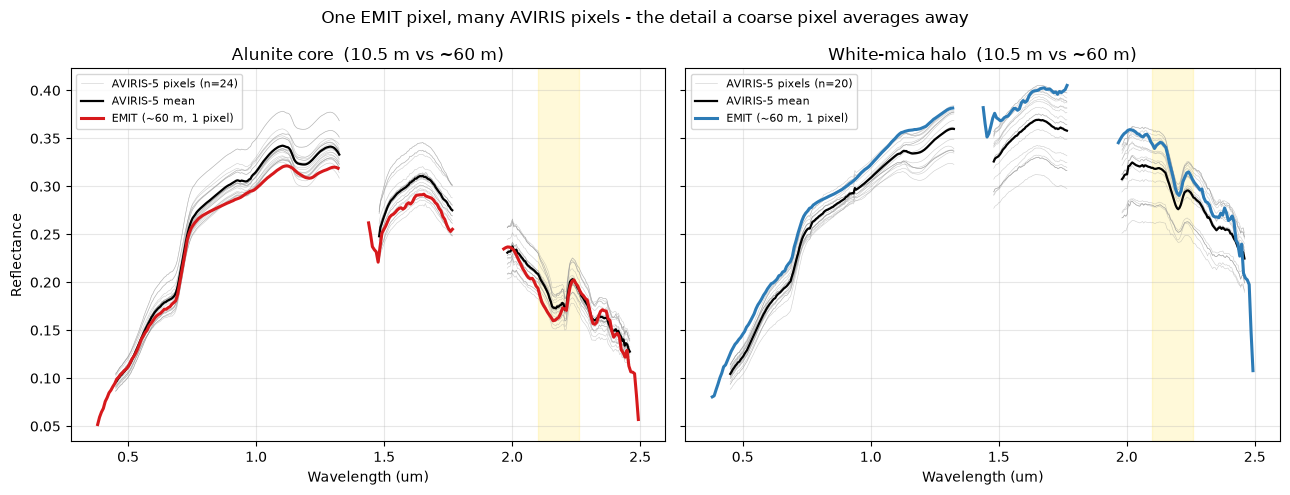

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (label, pt, color) in zip(axes, SITES):
    if pt is None:
        continue
    wa, R = aviris_pixels_in_emit_footprint(*pt)

    for i in range(R.shape[0]):                              # the individual airborne pixels
        ax.plot(wa, R[i], color="0.6", lw=0.4, alpha=0.5,
                label=f"AVIRIS-5 pixels (n={R.shape[0]})" if i == 0 else None)
    if R.shape[0]:                                           # their average
        ax.plot(wa, np.nanmean(R, axis=0), color="k", lw=1.6, label="AVIRIS-5 mean")

    we, re = emit_spectrum(*pt)                              # the single EMIT pixel
    ax.plot(we, re, color=color, lw=2.2, label="EMIT (~60 m, 1 pixel)")

    ax.axvspan(2.10, 2.26, color="gold", alpha=0.15)
    ax.set_title(f"{label}  ({AV_GSD:.1f} m vs ~60 m)")
    ax.set_xlabel("Wavelength (um)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

axes[0].set_ylabel("Reflectance")
fig.suptitle("One EMIT pixel, many AVIRIS pixels - the detail a coarse pixel averages away")
plt.tight_layout(); plt.savefig(FIG_DIR / "multiscale_spectra.png", dpi=130); plt.show()

## 7. Diagnosing Minerals from Absorption Features

Raw reflectance is dominated by overall brightness and continuum slope, which makes spectra awkward to compare. **Continuum removal** divides that broad shape out, leaving the absorption feature on a common baseline of 1.0.

We can then measure the feature **position**, where it bottoms out, and its **depth and width**. Alunite sits near 2.16-2.17 µm; white mica sits between 2.19 and 2.21 µm and shifts within that range with its aluminium content. That white mica shift tracks the composition of the altering fluid, and therefore its pH. These functions are in `vitals.spectral_utils`.

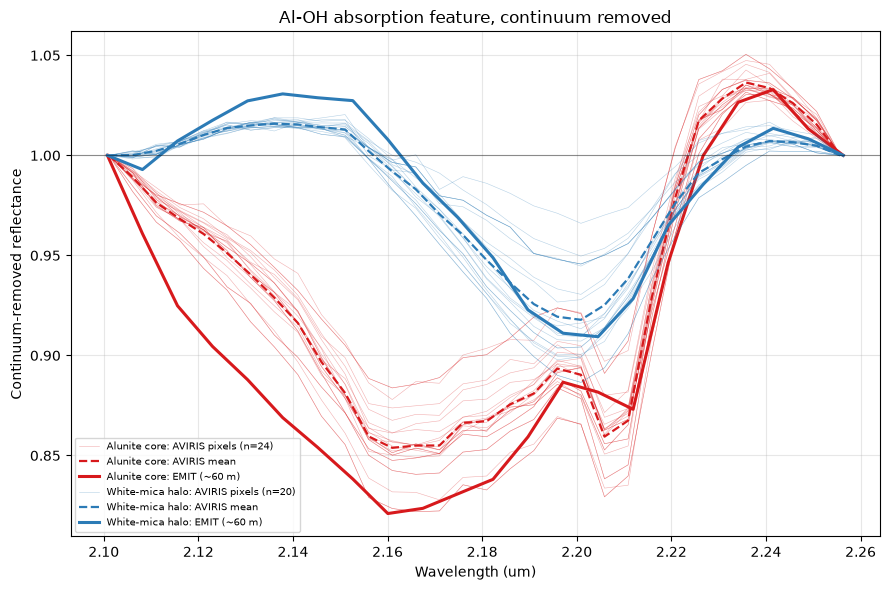

In [41]:
fig, ax = plt.subplots(figsize=(9, 6))
rows = []

def plot_continuum_removed(w_um, r, color, ls, lw, alpha=1.0, label=None):
    cw, cr = su.continuum_removed(w_um, r, wl_range=(2.10, 2.26))
    ax.plot(cw, cr, color=color, lw=lw, ls=ls, alpha=alpha, label=label)

for label, pt, color in SITES:
    if pt is None:
        continue
    wa, R = aviris_pixels_in_emit_footprint(*pt)

    # Each airborne pixel, and where its feature bottoms out
    positions = []
    for i in range(R.shape[0]):
        plot_continuum_removed(wa, R[i], color, "-", 0.4, alpha=0.35,
                               label=f"{label}: AVIRIS pixels (n={R.shape[0]})" if i == 0 else None)
        p = su.aloh_feature_metrics(wa, R[i])["min_wavelength_um"]
        if np.isfinite(p):
            positions.append(p)

    if R.shape[0]:                                    # the airborne average
        r_mean = np.nanmean(R, axis=0)
        plot_continuum_removed(wa, r_mean, color, "--", 1.6, label=f"{label}: AVIRIS mean")
        rows.append(("AVIRIS-5 mean", label, su.aloh_feature_metrics(wa, r_mean),
                     np.nanstd(positions) if positions else np.nan, R.shape[0]))

    we, re = emit_spectrum(*pt)                       # the single EMIT pixel
    plot_continuum_removed(we, re, color, "-", 2.2, label=f"{label}: EMIT (~60 m)")
    rows.append(("EMIT", label, su.aloh_feature_metrics(we, re), np.nan, 1))

ax.axhline(1.0, color="k", lw=0.8, alpha=0.4)         # the shared continuum baseline
ax.set_xlabel("Wavelength (um)"); ax.set_ylabel("Continuum-removed reflectance")
ax.set_title("Al-OH absorption feature, continuum removed")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "continuum_removed.png", dpi=130); plt.show()

In [42]:
# Summarise the feature measurements collected while plotting
metrics = pd.DataFrame([
    {"sensor": sensor, "site": site,
     "Al-OH position (um)": round(m["min_wavelength_um"], 4),
     "band depth": round(m["band_depth"], 3),
     "position spread (nm)": round(spread * 1000, 1) if np.isfinite(spread) else np.nan,
     "n pixels": n}
    for sensor, site, m, spread, n in rows
])
metrics

,sensor,site,Al-OH position (um),band depth,position spread (nm),n pixels
0,AVIRIS-5 mean,Alunite core,2.1627,0.146,12.4,24
1,EMIT,Alunite core,2.1628,0.179,NaN,1
2,AVIRIS-5 mean,White-mica halo,2.1992,0.082,1.1,20
3,EMIT,White-mica halo,2.2014,0.091,NaN,1


### 7.1 Reading the Metrics

Compare the EMIT row against the AVIRIS-5 mean row for each site. If the two scales recover similar feature positions, that is a direct check that EMIT's regional map reflects what is on the ground.

The `position spread` column is the standard deviation of the feature position across the individual airborne pixels inside one EMIT footprint. A small spread means the footprint is spectrally uniform and EMIT's single value represents it well; a large spread means EMIT is averaging over a mixture only the airborne scale resolves.

> As a guide when reading positions: **2.16-2.17 µm** indicates alunite and acidic conditions, while **2.19-2.21 µm** indicates white mica, with shorter wavelengths meaning more aluminium-rich and higher pH.

### 7.2 The white-mica composition shift as an image
#TODO


## 8. Summary

In this notebook we searched the NASA Earthdata archive for EMIT and AVIRIS-5 data over a study area in the southern Wah Wah Range, screened the EMIT scenes for the alteration minerals relevant to critical-mineral exploration, mapped where those minerals occur, and then dropped to the airborne scale to see what the coarse pixels were averaging.

Three points are worth carrying forward:

1. **Screen on content, not just metadata.** Cloud cover and acquisition date are easy to filter on, but they do not tell you whether the minerals you care about were identified. Opening a few candidate scenes and counting is inexpensive and far more informative.
2. **The retrieval varies even when the geology does not.** Every scene in our screening table images the same rocks, yet the indicator counts differ substantially. That spread is a property of the retrieval, and a good reason to look at more than one scene.
3. **Scale is a real effect.** Inside a single EMIT pixel the airborne spectra are not identical. EMIT trades that detail for global, repeated coverage, which is why the two scales work well together.

The alunite core and surrounding white-mica halo are surface expressions of the hydrothermal system developed in the Blawn Formation rhyolites mapped across this area. Those evolved, A-type rhyolites carry the lithophile critical-metal suite - Be, Li, Mo, Sn, W, REE, U, and F. Mapping alteration is not the same as finding metals, but it is a systematic and inexpensive way to decide where to look harder.

### Extending this Notebook
- Use the Al-OH feature width to separate alunite-rich from pyrophyllite-rich zones.
- Map the white-mica position across the scene to produce a fluid-composition proxy image.
- Run the same feature analysis across the full AVIRIS-5 flight line.
- Bring in the L2BMINUNCERT `fit` values as a confidence layer on every product.
- Compare against the Utah Geological Survey surface geochemistry collected over this area.

### Data Citations
- EMIT L2B Mineralogy - DOI 10.5067/EMIT/EMITL2BMIN.001 (LP DAAC)
- EMIT L2A Reflectance - DOI 10.5067/EMIT/EMITL2ARFL.001 (LP DAAC)
- AVIRIS-5 L2A Orthocorrected Surface Reflectance - DOI 10.3334/ORNLDAAC/2484 (ORNL DAAC)
- Utah Geological Survey, Open-File Report 671, Southern Pine Valley area, Beaver County, Utah

## Contact Info:  

Email: LPDAAC@usgs.gov  
Voice: +1-866-573-3222  
Organization: Land Processes Distributed Active Archive Center (LP DAAC)¹  
Website: <https://www.earthdata.nasa.gov/centers/lp-daac>  

¹Work performed under USGS contract 140G0126D0001 for NASA contract NNG14HH33I. 